### Failed experiment 

In [1]:
import polars as pl
import numpy as np

import matplotlib.pyplot as plt
import yaml
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.model_selection import train_test_split


import src.data.utils as dutils
from src.models.vision_finetuned import ResNetFTv01

In [2]:
PATH = "../data/raw/cifar-10-python.tar/cifar-10-python/cifar-10-batches-py/"
comb_df, test_df = dutils.read_data_v2(PATH)

with open("../configs/base_config.yaml", 'r') as f:
    base_config = yaml.safe_load(f)

comb_df.shape, test_df.shape

C:\Work\Project\cv-architecture-sprint-cifar\src\data\utils.py:10: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = pickle.load(fo, encoding='bytes')


((50000, 3), (10000, 3))

In [3]:
torch.manual_seed(base_config["base"]["random_state"])
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
X = comb_df["data"]; y = comb_df["label"]
X_test = test_df["data"]; y_test = test_df["label"]
X_train, X_val, y_train, y_val = train_test_split(X, y, 
                                                  test_size=base_config["base"]["val_split"], 
                                                  random_state=base_config["base"]["random_state"], 
                                                  stratify=y)


print("Train size: ", X_train.shape, y_train.shape)
print("Test size: ", X_test.shape, y_test.shape)
print("Val size: ", X_val.shape, y_val.shape)

Train size:  (40000,) (40000,)
Test size:  (10000,) (10000,)
Val size:  (10000,) (10000,)


In [5]:
train_df = pl.DataFrame({"data": X_train, "label": y_train})
val_df = pl.DataFrame({"data": X_val, "label": y_val})

train_df.shape, val_df.shape

((40000, 2), (10000, 2))

In [6]:
train_dataset = dutils.CIFARData(train_df)
test_dataset = dutils.CIFARData(test_df)
val_dataset = dutils.CIFARData(val_df)

train_loader = DataLoader(train_dataset, 
                         batch_size=base_config["neural"]["train_batch_size"], shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, 
                       batch_size=base_config["neural"]["batch_size"], num_workers=2)
test_loader = DataLoader(test_dataset, 
                        batch_size=base_config["neural"]["batch_size"], num_workers=2)

In [7]:
net = ResNetFTv01(
    n_classes=len(y.unique())
).to(base_config["base"]["gpu"])
optim = torch.optim.AdamW(net.parameters(), lr=1e-3, 
                          weight_decay=1e-2)
criterion = nn.CrossEntropyLoss()

In [9]:
from sklearn.metrics import confusion_matrix
from tqdm import tqdm

history = {
    "train_loss": [],
    "val_loss": [],
    "cm": []
}

for epoch in  tqdm(range(1,10 + 1), total=10):
    y_val_pred = []
    y_val = []
    
    train_loss = 0.0
    
    net.train()
    for step, batch in tqdm(enumerate(train_loader, 1), total=len(train_loader), desc="Training"):
        optim.zero_grad()
        
        _data = batch["data"]
        _label = batch["label"].to(base_config["base"]["gpu"]).reshape((-1))
        
        _data = _data.reshape((_data.shape[0], 32, 32, 3))
        _data = np.transpose(_data, (0, 3, 1, 2))
        _data = _data.to(base_config["base"]["gpu"])
        
        
        logit = net(_data)
        loss = criterion(logit, _label)
        
        loss.backward()
        optim.step()
        
        train_loss += loss
    train_loss = train_loss / len(train_loader)
    print(f"Training loss on epoch: {epoch}: {train_loss}")
    
    val_loss = 0.0
    net.eval()
    with torch.no_grad():
        for step, batch in enumerate(val_loader, 1):
            _data = batch["data"]
            _label = batch["label"].to(base_config["base"]["gpu"]).reshape((-1))
            
            _data = _data.reshape((_data.shape[0], 32, 32, 3))
            _data = np.transpose(_data, (0, 3, 1, 2))
            _data = _data.to(base_config["base"]["gpu"])
            
            logit = net(_data)
            loss = criterion(logit, _label)
            
            val_loss += loss
            y_pred = logit.argmax(1)
            
            y_val.extend(_label.cpu().numpy())
            y_val_pred.extend(y_pred.cpu().numpy())
    val_loss = val_loss / len(val_loader)
    print(f"Val loss on epoch: {epoch}: {val_loss}")
    
    cm = confusion_matrix(y_val, y_val_pred)
    print(cm)
    
    history["train_loss"].append(train_loss.detach().cpu().numpy())
    history["val_loss"].append(val_loss.detach().cpu().numpy())
    history["cm"].append(cm)

Training: 100%|██████████| 1250/1250 [02:37<00:00,  7.94it/s]


Training loss on epoch: 1: 1.8662747144699097


 10%|█         | 1/10 [02:51<25:41, 171.33s/it]

Val loss on epoch: 1: 1.734834909439087
[[509  73  50  19  19  10  34  41 138 107]
 [ 69 365   5  13   8  15  50  59  69 347]
 [106  44 256 118 106  63 158  56  38  55]
 [ 49  55  68 239  69 151 133 110  31  95]
 [ 80  50  98  57 245  34 198 137  49  52]
 [ 47  57  88 210  53 257  98  86  25  79]
 [ 43  61  68  86  80  60 465  66  19  52]
 [ 51  76  32  83  77  46  80 388  19 148]
 [207  97  22  23  17  14  24  25 438 133]
 [ 66 128   4  25   7  17  43  65  53 592]]


Training: 100%|██████████| 1250/1250 [02:38<00:00,  7.89it/s]


...

Val loss on epoch: 9: 1.566650390625
[[523  78  54  10  24  27  20  30 190  44]
 [ 52 643   9  28  12   8  15  35  53 145]
 [ 98  61 303  90 130  86  91  75  26  40]
 [ 44  63  93 242  96 177  88 104  36  57]
 [ 44  62 101  51 340  41  99 173  61  28]
 [ 26  74  80 174  69 352  55 122  17  31]
 [ 23  78  84  78 111  60 441  68  19  38]
 [ 35  93  29  65  64  48  27 527  24  88]
 [154 129  25   9  15  14   7  25 568  54]
 [ 47 280   9  28  15  19  23  73  49 457]]


Training: 100%|██████████| 1250/1250 [02:43<00:00,  7.63it/s]


Training loss on epoch: 10: 1.4374170303344727


100%|██████████| 10/10 [28:45<00:00, 172.52s/it]

Val loss on epoch: 10: 1.573416829109192
[[535  46  91  18  42  14  18  20 164  52]
 [ 60 496  20  24  26  17  41  40  87 189]
 [ 87  23 363  97 178  60 106  30  35  21]
 [ 38  22 132 251  90 181 153  53  28  52]
 [ 52  29 116  68 434  42 121  68  42  28]
 [ 27  30 112 195  84 333 111  50  29  29]
 [ 32  43  80  87 135  46 508  23  15  31]
 [ 42  41  50  81 184  57  59 398  16  72]
 [174  71  38  19  29  18  17  18 569  47]
 [ 51 164  33  41  37  26  45  69  64 470]]


In [10]:
import os

meta = os.path.join(PATH, "batches.meta")

metadata = dutils.read_pkl(meta)
label_name = [l.decode("utf-8") for l in metadata[b'label_names']]

In [13]:
from src.eval.metrics import format_cm, evaluate
y_test_v = []
y_test_pred = []

net.eval()
with torch.no_grad():
    for step, batch in enumerate(test_loader, 1):
        _data = batch["data"]
        _label = batch["label"].to(base_config["base"]["gpu"]).reshape((-1))
        
        _data = _data.reshape((_data.shape[0], 32, 32, 3))
        _data = np.transpose(_data, (0, 3, 1, 2))
        _data = _data.to(base_config["base"]["gpu"])
        
        logit = net(_data)
        y_pred = logit.argmax(1)
        
        y_test_v.extend(_label.cpu().numpy())
        y_test_pred.extend(y_pred.cpu().numpy())

cm = evaluate(y_test_v, y_test_pred)
format_cm(cm, class_names=label_name, normalize=True)

              precision    recall  f1-score   support

           0     0.4774    0.5480    0.5102      1000
           1     0.4852    0.4580    0.4712      1000
           2     0.3577    0.3810    0.3690      1000
           3     0.3169    0.2640    0.2881      1000
           4     0.3689    0.4390    0.4009      1000
           5     0.4040    0.3260    0.3608      1000
           6     0.4722    0.5430    0.5051      1000
           7     0.5173    0.4030    0.4531      1000
           8     0.5362    0.5930    0.5632      1000
           9     0.4714    0.4610    0.4661      1000

    accuracy                         0.4416     10000
   macro avg     0.4407    0.4416    0.4388     10000
weighted avg     0.4407    0.4416    0.4388     10000



,Pred: airplane,Pred: automobile,Pred: bird,Pred: cat,Pred: deer,Pred: dog,Pred: frog,Pred: horse,Pred: ship,Pred: truck
True: airplane,0.548,0.054,0.075,0.019,0.038,0.007,0.025,0.016,0.175,0.043
True: automobile,0.063,0.458,0.033,0.030,0.033,0.013,0.034,0.040,0.097,0.199
True: bird,0.105,0.035,0.381,0.072,0.151,0.078,0.100,0.026,0.032,0.020
True: cat,0.037,0.035,0.147,0.264,0.081,0.162,0.125,0.056,0.036,0.057
True: deer,0.046,0.028,0.115,0.064,0.439,0.046,0.135,0.065,0.043,0.019
True: dog,0.039,0.015,0.119,0.197,0.084,0.326,0.095,0.071,0.028,0.026
True: frog,0.022,0.038,0.086,0.065,0.142,0.038,0.543,0.022,0.015,0.029
True: horse,0.042,0.047,0.050,0.061,0.152,0.102,0.047,0.403,0.022,0.074
True: ship,0.165,0.062,0.034,0.021,0.029,0.016,0.013,0.017,0.593,0.050
True: truck,0.081,0.172,0.025,0.040,0.041,0.019,0.033,0.063,0.065,0.461


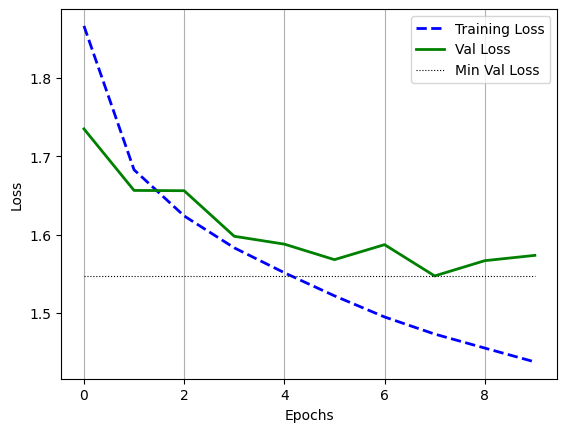

In [14]:
from src.utils import plot_neural
plot_neural(
    epochs= len(history["train_loss"]), train_loss= history["train_loss"], val_loss = history["val_loss"]
)

In [15]:
torch.save(net.state_dict(), "../artifacts/resnet_ft_v01.pth")

---

In [8]:
from src.models.vision_finetuned import ResNetFTv02

net2 = ResNetFTv02(
    n_classes=len(y.unique())
).to(base_config["base"]["gpu"])
optim = torch.optim.AdamW(net2.parameters(), lr=1e-3, 
                          weight_decay=1e-2)
criterion = nn.CrossEntropyLoss()

In [9]:
from sklearn.metrics import confusion_matrix
from tqdm import tqdm

history = {
    "train_loss": [],
    "val_loss": [],
    "cm": []
}

for epoch in  tqdm(range(1,10 + 1), total=10):
    y_val_pred = []
    y_val = []
    
    train_loss = 0.0
    
    net2.train()
    for step, batch in tqdm(enumerate(train_loader, 1), total=len(train_loader), desc="Training"):
        optim.zero_grad()
        
        _data = batch["data"]
        _label = batch["label"].to(base_config["base"]["gpu"]).reshape((-1))
        
        _data = _data.reshape((_data.shape[0], 32, 32, 3))
        _data = np.transpose(_data, (0, 3, 1, 2))
        _data = _data.to(base_config["base"]["gpu"])
        
        
        logit = net2(_data)
        loss = criterion(logit, _label)
        
        loss.backward()
        optim.step()
        
        train_loss += loss
    train_loss = train_loss / len(train_loader)
    print(f"Training loss on epoch: {epoch}: {train_loss}")
    
    val_loss = 0.0
    net2.eval()
    with torch.no_grad():
        for step, batch in enumerate(val_loader, 1):
            _data = batch["data"]
            _label = batch["label"].to(base_config["base"]["gpu"]).reshape((-1))
            
            _data = _data.reshape((_data.shape[0], 32, 32, 3))
            _data = np.transpose(_data, (0, 3, 1, 2))
            _data = _data.to(base_config["base"]["gpu"])
            
            logit = net2(_data)
            loss = criterion(logit, _label)
            
            val_loss += loss
            y_pred = logit.argmax(1)
            
            y_val.extend(_label.cpu().numpy())
            y_val_pred.extend(y_pred.cpu().numpy())
    val_loss = val_loss / len(val_loader)
    print(f"Val loss on epoch: {epoch}: {val_loss}")
    
    cm = confusion_matrix(y_val, y_val_pred)
    print(cm)
    
    history["train_loss"].append(train_loss.detach().cpu().numpy())
    history["val_loss"].append(val_loss.detach().cpu().numpy())
    history["cm"].append(cm)

Training: 100%|██████████| 1250/1250 [00:18<00:00, 68.13it/s]


Training loss on epoch: 1: 2.0912764072418213


 10%|█         | 1/10 [00:30<04:36, 30.68s/it]

Val loss on epoch: 1: 1.9969587326049805
[[288 100 128  26  40  39  40  49 228  62]
 [ 45 335  38  47  24  49  63 103 122 174]
 [ 88  58 295  96  57 101 110  79  69  47]
 [ 35  91 103 200  53 165  96 111  43 103]
 [ 85  83 166  91 144  51 123 102 103  52]
 [ 36  87 102 166  31 261 103 107  40  67]
 [ 49  73 161  90 111  83 259  88  39  47]
 [ 37 139  64  88  71  95  79 237  48 142]
 [158 111  59  30  41  24  37  51 396  93]
 [ 51 192  23  61  23  44  50 137  83 336]]


Training: 100%|██████████| 1250/1250 [00:17<00:00, 71.23it/s]


...

Val loss on epoch: 9: 1.911293625831604
[[417  63  84  17  48  54  56  27 196  38]
 [ 77 303  13  28  36  73  77  81 144 168]
 [134  46 224  54 113 145 139  45  59  41]
 [ 56  59  77 134  81 278 118  63  42  92]
 [102  53  96  47 242  90 159  75  86  50]
 [ 53  80  65  98  85 365 102  65  38  49]
 [ 69  52  72  48 134 100 382  48  46  49]
 [ 60 116  43  53  91 155 104 202  48 128]
 [167  81  35  23  58  34  29  23 459  91]
 [ 71 163  20  41  33  74  56  86 116 340]]


Training: 100%|██████████| 1250/1250 [00:18<00:00, 66.95it/s]


Training loss on epoch: 10: 1.8764827251434326


100%|██████████| 10/10 [05:02<00:00, 30.27s/it]

Val loss on epoch: 10: 1.90044367313385
[[370  78  98  18  44  56  70  38 173  55]
 [ 63 336  16  29  24  88  85  82 100 177]
 [ 91  36 263  49 113 143 176  54  36  39]
 [ 45  56  71 120  67 309 141  76  30  85]
 [ 88  69  94  43 199  93 194 103  60  57]
 [ 35  64  73  84  58 395 147  70  24  50]
 [ 52  60  60  46  93 113 458  50  21  47]
 [ 50 120  49  40  55 167 136 231  34 118]
 [147 114  35  20  52  51  47  34 408  92]
 [ 62 174  15  34  16 101  67 105  76 350]]


In [12]:
from src.eval.metrics import format_cm, evaluate
y_test_v2 = []
y_test_pred2 = []

net2.eval()
with torch.no_grad():
    for step, batch in enumerate(test_loader, 1):
        _data = batch["data"]
        _label = batch["label"].to(base_config["base"]["gpu"]).reshape((-1))
        
        _data = _data.reshape((_data.shape[0], 32, 32, 3))
        _data = np.transpose(_data, (0, 3, 1, 2))
        _data = _data.to(base_config["base"]["gpu"])
        
        logit = net2(_data)
        y_pred = logit.argmax(1)
        
        y_test_v2.extend(_label.cpu().numpy())
        y_test_pred2.extend(y_pred.cpu().numpy())

cm2 = evaluate(y_test_v2, y_test_pred2)
format_cm(cm2, class_names=label_name, normalize=True)

              precision    recall  f1-score   support

           0     0.3756    0.3730    0.3743      1000
           1     0.3115    0.3470    0.3283      1000
           2     0.2870    0.2230    0.2510      1000
           3     0.2383    0.1070    0.1477      1000
           4     0.3024    0.2150    0.2513      1000
           5     0.2721    0.4090    0.3268      1000
           6     0.2971    0.4680    0.3635      1000
           7     0.2743    0.2370    0.2543      1000
           8     0.4267    0.3900    0.4075      1000
           9     0.3400    0.3740    0.3562      1000

    accuracy                         0.3143     10000
   macro avg     0.3125    0.3143    0.3061     10000
weighted avg     0.3125    0.3143    0.3061     10000



,Pred: airplane,Pred: automobile,Pred: bird,Pred: cat,Pred: deer,Pred: dog,Pred: frog,Pred: horse,Pred: ship,Pred: truck
True: airplane,0.373,0.072,0.110,0.015,0.055,0.049,0.075,0.035,0.170,0.046
True: automobile,0.072,0.347,0.017,0.017,0.021,0.085,0.091,0.093,0.076,0.181
True: bird,0.101,0.050,0.223,0.058,0.098,0.155,0.189,0.054,0.040,0.032
True: cat,0.042,0.063,0.072,0.107,0.054,0.297,0.171,0.073,0.034,0.087
True: deer,0.068,0.070,0.112,0.037,0.215,0.086,0.211,0.095,0.056,0.050
True: dog,0.030,0.060,0.080,0.082,0.052,0.409,0.123,0.079,0.013,0.072
True: frog,0.039,0.059,0.062,0.043,0.096,0.109,0.468,0.055,0.026,0.043
True: horse,0.042,0.105,0.049,0.048,0.053,0.170,0.126,0.237,0.038,0.132
True: ship,0.169,0.103,0.037,0.022,0.050,0.058,0.057,0.031,0.390,0.083
True: truck,0.057,0.185,0.015,0.020,0.017,0.085,0.064,0.112,0.071,0.374


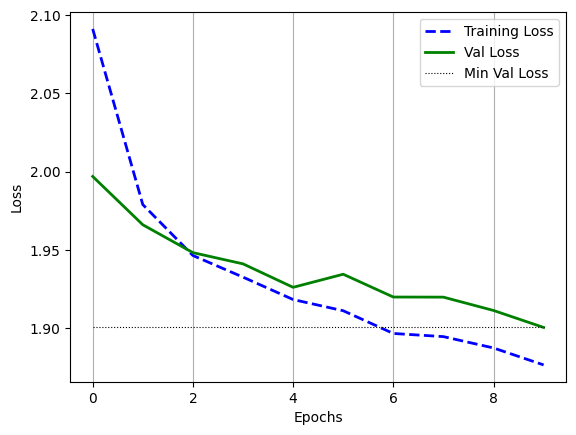

In [13]:
from src.utils import plot_neural
plot_neural(
    epochs= len(history["train_loss"]), train_loss= history["train_loss"], val_loss = history["val_loss"]
)

In [14]:
torch.save(net2.state_dict(), "../artifacts/resnet_ft_v02.pth")


---

In [15]:
# from src.models.vision_finetuned import ResNetFTv02

net3 = ResNetFTv02(
    n_classes=len(y.unique())
).to(base_config["base"]["gpu"])
optim = torch.optim.AdamW(net3.parameters(), lr=1e-3, 
                          weight_decay=1e-2)
criterion = nn.CrossEntropyLoss()

In [16]:
from sklearn.metrics import confusion_matrix
from tqdm import tqdm

history3 = {
    "train_loss": [],
    "val_loss": [],
    "cm": []
}

for epoch in  tqdm(range(1,50 + 1), total=10):
    y_val_pred = []
    y_val = []
    
    train_loss = 0.0
    
    net3.train()
    for step, batch in tqdm(enumerate(train_loader, 1), total=len(train_loader), desc="Training"):
        optim.zero_grad()
        
        _data = batch["data"]
        _label = batch["label"].to(base_config["base"]["gpu"]).reshape((-1))
        
        _data = _data.reshape((_data.shape[0], 32, 32, 3))
        _data = np.transpose(_data, (0, 3, 1, 2))
        _data = _data.to(base_config["base"]["gpu"])
        
        
        logit = net3(_data)
        loss = criterion(logit, _label)
        
        loss.backward()
        optim.step()
        
        train_loss += loss
    train_loss = train_loss / len(train_loader)
    print(f"Training loss on epoch: {epoch}: {train_loss}")
    
    val_loss = 0.0
    net3.eval()
    with torch.no_grad():
        for step, batch in enumerate(val_loader, 1):
            _data = batch["data"]
            _label = batch["label"].to(base_config["base"]["gpu"]).reshape((-1))
            
            _data = _data.reshape((_data.shape[0], 32, 32, 3))
            _data = np.transpose(_data, (0, 3, 1, 2))
            _data = _data.to(base_config["base"]["gpu"])
            
            logit = net3(_data)
            loss = criterion(logit, _label)
            
            val_loss += loss
            y_pred = logit.argmax(1)
            
            y_val.extend(_label.cpu().numpy())
            y_val_pred.extend(y_pred.cpu().numpy())
    val_loss = val_loss / len(val_loader)
    print(f"Val loss on epoch: {epoch}: {val_loss}")
    
    cm = confusion_matrix(y_val, y_val_pred)
    print(cm)
    
    history3["train_loss"].append(train_loss.detach().cpu().numpy())
    history3["val_loss"].append(val_loss.detach().cpu().numpy())
    history3["cm"].append(cm)

Training: 100%|██████████| 1250/1250 [00:18<00:00, 67.11it/s]


Training loss on epoch: 1: 2.0916805267333984


 10%|█         | 1/10 [00:31<04:44, 31.60s/it]

Val loss on epoch: 1: 2.006702423095703
[[361  88  75  32  59  49  98  48 139  51]
 [ 84 323  16  41  22  59 120  99  53 183]
 [107  69 167  74  96 118 213  72  41  43]
 [ 47  74  69 147  62 186 187 117  28  83]
 [107  96  79  51 165  62 244  96  42  58]
 [ 42  94  55 135  60 269 166 104  20  55]
 [ 44  72  61  81  80  75 450  64  22  51]
 [ 46 131  27  73  69 109 144 236  27 138]
 [225 129  48  38  66  23  72  42 256 101]
 [ 66 195  16  50  25  57  78 136  56 321]]


Training: 100%|██████████| 1250/1250 [00:18<00:00, 68.35it/s]


...

Val loss on epoch: 49: 1.9090014696121216
[[387 102  63  35  54  31  52  26 213  37]
 [ 65 393  10  39  33  42  70  77 123 148]
 [161  58 199  75 121  96 157  37  56  40]
 [ 51  73  77 234  99 151 124  66  55  70]
 [107  63  87  78 264  49 156  79  72  45]
 [ 46  87  72 193  82 255 120  70  31  44]
 [ 74  67  77  76 129  54 392  53  40  38]
 [ 61 130  28  89  94 105  95 226  53 119]
 [158 113  23  37  62  17  35  23 447  85]
 [ 64 213  13  57  26  41  58  99  96 333]]


Training: 100%|██████████| 1250/1250 [00:17<00:00, 72.17it/s]


Training loss on epoch: 50: 1.7930628061294556


50it [25:28, 30.58s/it]

Val loss on epoch: 50: 1.9009220600128174
[[430 106  70  32  49  31  48  30 157  47]
 [ 76 395  16  37  30  36  70  86  97 157]
 [134  61 218  73 120  94 146  66  42  46]
 [ 52  82  76 220  90 163 124  72  42  79]
 [113  68  92  76 259  44 158  94  48  48]
 [ 50  86  63 157  86 280 116  78  25  59]
 [ 63  70  89  66 107  55 395  58  45  52]
 [ 52 124  30  78  87  94 101 272  41 121]
 [186 132  24  29  53  21  39  42 395  79]
 [ 65 206  15  60  37  38  45 113  83 338]]


In [17]:
from src.eval.metrics import format_cm, evaluate
y_test_v3 = []
y_test_pred3 = []

net3.eval()
with torch.no_grad():
    for step, batch in enumerate(test_loader, 1):
        _data = batch["data"]
        _label = batch["label"].to(base_config["base"]["gpu"]).reshape((-1))
        
        _data = _data.reshape((_data.shape[0], 32, 32, 3))
        _data = np.transpose(_data, (0, 3, 1, 2))
        _data = _data.to(base_config["base"]["gpu"])
        
        logit = net3(_data)
        y_pred = logit.argmax(1)
        
        y_test_v3.extend(_label.cpu().numpy())
        y_test_pred3.extend(y_pred.cpu().numpy())

cm3 = evaluate(y_test_v3, y_test_pred3)
format_cm(cm3, class_names=label_name, normalize=True)

              precision    recall  f1-score   support

           0     0.3534    0.4460    0.3943      1000
           1     0.3122    0.4140    0.3560      1000
           2     0.3001    0.2110    0.2478      1000
           3     0.2241    0.1620    0.1880      1000
           4     0.2732    0.2440    0.2578      1000
           5     0.3382    0.2770    0.3046      1000
           6     0.3128    0.4210    0.3589      1000
           7     0.2796    0.2690    0.2742      1000
           8     0.4253    0.3870    0.4052      1000
           9     0.3513    0.3710    0.3609      1000

    accuracy                         0.3202     10000
   macro avg     0.3170    0.3202    0.3148     10000
weighted avg     0.3170    0.3202    0.3148     10000



,Pred: airplane,Pred: automobile,Pred: bird,Pred: cat,Pred: deer,Pred: dog,Pred: frog,Pred: horse,Pred: ship,Pred: truck
True: airplane,0.446,0.083,0.087,0.020,0.061,0.028,0.039,0.037,0.143,0.056
True: automobile,0.070,0.414,0.021,0.020,0.041,0.033,0.071,0.092,0.086,0.152
True: bird,0.123,0.065,0.211,0.092,0.115,0.083,0.170,0.058,0.039,0.044
True: cat,0.073,0.091,0.082,0.162,0.083,0.140,0.170,0.087,0.037,0.075
True: deer,0.092,0.070,0.093,0.068,0.244,0.041,0.182,0.100,0.056,0.054
True: dog,0.055,0.088,0.076,0.143,0.068,0.277,0.112,0.109,0.019,0.053
True: frog,0.047,0.079,0.062,0.075,0.114,0.052,0.421,0.061,0.033,0.056
True: horse,0.055,0.127,0.040,0.076,0.080,0.100,0.089,0.269,0.045,0.119
True: ship,0.239,0.102,0.017,0.024,0.050,0.027,0.048,0.030,0.387,0.076
True: truck,0.062,0.207,0.014,0.043,0.037,0.038,0.044,0.119,0.065,0.371


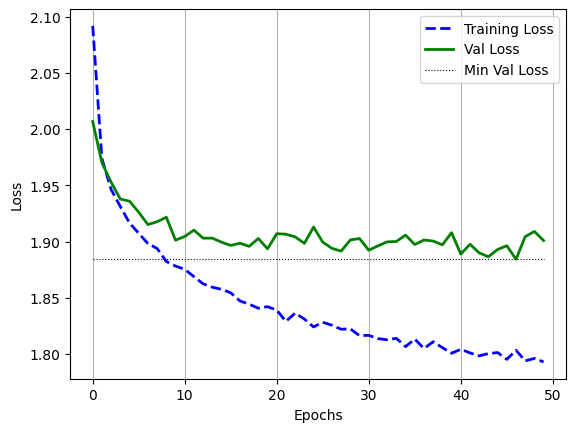

In [18]:
from src.utils import plot_neural
plot_neural(
    epochs= len(history3["train_loss"]), train_loss= history3["train_loss"], val_loss = history3["val_loss"]
)

In [19]:
torch.save(net3.state_dict(), "../artifacts/resnet_ft2_v02.pth")

In [11]:
from torchvision import transforms

train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616)),
])

In [12]:
for step, batch in enumerate(train_loader, 1):
    
    _data = batch["data"]
    _label = batch["label"].to(base_config["base"]["gpu"]).reshape((-1))
    
    _data = _data.reshape((_data.shape[0], 32, 32, 3))
    _data = np.transpose(_data, (0, 3, 1, 2))
    _data = _data / 255
    _data = train_tf(_data)
    print(_data)
    break
    # _data = _data.to(base_config["base"]["gpu"])

tensor([[[[-1.9895, -1.9895, -1.9895,  ..., -1.9895, -1.9895, -1.9895],
          [-1.9895, -1.9895, -1.9895,  ..., -1.9895, -1.9895, -1.9895],
          [-1.9895, -1.9895, -1.9895,  ..., -1.9895, -1.9895, -1.9895],
          ...,
          [-0.6876, -0.5288, -0.3859,  ..., -1.9895, -1.9895, -1.9895],
          [-0.9734, -1.1004,  0.8842,  ..., -1.9895, -1.9895, -1.9895],
          [-1.3068, -1.7354,  0.0745,  ..., -1.9895, -1.9895, -1.9895]],

         [[-1.9803, -1.9803, -1.9803,  ..., -1.9803, -1.9803, -1.9803],
          [-1.9803, -1.9803, -1.9803,  ..., -1.9803, -1.9803, -1.9803],
          [-1.9803, -1.9803, -1.9803,  ..., -1.9803, -1.9803, -1.9803],
          ...,
          [-0.7241, -0.5147, -0.3859,  ..., -1.9803, -1.9803, -1.9803],
          [-1.2556, -1.3200,  0.8542,  ..., -1.9803, -1.9803, -1.9803],
          [-0.8368, -1.6743, -0.2571,  ..., -1.9803, -1.9803, -1.9803]],

         [[-1.7068, -1.7068, -1.7068,  ..., -1.7068, -1.7068, -1.7068],
          [-1.7068, -1.7068, -

In [16]:
from sklearn.metrics import accuracy_score

In [17]:
import torch
import torch.nn as nn
import torchvision.models as ftmodels

base_model = ftmodels.mobilenet_v2(weights="DEFAULT")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to C:\Users\apmal/.cache\torch\hub\checkpoints\mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 52.5MB/s]


In [21]:
base_model

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [20]:
base_model = ftmodels.mobilenet_v2(weights=None)